# Notebook 6 — CRTBP, puntos de Lagrange y Constante de Jacobi
## El sistema Sol–Tierra–Apophis como problema de tres cuerpos

**Autor:** Soleil Dayana Niño Murcia  
**Curso:** Mecánica Celeste  
**Fecha:** Mayo 2026

---

### Resumen Ejecutivo
Este estudio analiza la estabilidad dinámica del asteroide **99942 Apophis** durante su encuentro cercano con la Tierra en abril de 2029. Utilizando el **Problema Circular Restringido de Tres Cuerpos (CRTBP)**, determinamos que el asteroide no puede ser capturado gravitacionalmente por la Tierra debido a que su constante de Jacobi es inferior a los umbrales de los puntos de Lagrange L1/L2.
### Contexto Teórico Concreto
1. **CRTBP:** Aproximación donde el Sol y la Tierra orbitan circularmente y el asteroide es una masa infinitesimal. La única constante del movimiento es la **Constante de Jacobi ($C_J$)**.
2. **Superficies de Velocidad Cero:** Regiones del espacio donde la energía del objeto le prohíbe el acceso. Los puntos de equilibrio $L_1$ y $L_2$ actúan como "puertas" energéticas.

## Bloque A — CRTBP y Constante de Jacobi

### A.1 Teoría: El Problema Circular Restringido de Tres Cuerpos

El **CRTBP** describe el movimiento de una partícula de masa despreciable (Apophis) en el campo
gravitacional de dos cuerpos primarios que orbitan circularmente (Sol y Tierra).

#### Sistema de referencia rotante

Se adopta un sistema que rota con la frecuencia orbital de la Tierra ($n = 2\pi/T$), donde:
- El **Sol** se ubica en $(-\mu, 0)$ y la **Tierra** en $(1-\mu, 0)$
- El parámetro de masa: $\mu = M_\oplus / (M_\odot + M_\oplus) \approx 3 \times 10^{-6}$
- La distancia Sol-Tierra se normaliza a 1

#### Potencial efectivo

$$\Omega(x, y) = \frac{1-\mu}{r_1} + \frac{\mu}{r_2} + \frac{x^2 + y^2}{2}$$

donde $r_1 = \sqrt{(x+\mu)^2 + y^2}$ (distancia al Sol) y $r_2 = \sqrt{(x-1+\mu)^2 + y^2}$ (a la Tierra).

#### Constante de Jacobi

La **única cuadratura** del CRTBP es la constante de Jacobi:

$$\boxed{C_J = 2\Omega(x,y) - v^2}$$

donde $v^2 = \dot{x}^2 + \dot{y}^2$ es la velocidad en el marco rotante. $C_J$ se conserva a lo largo
de cualquier trayectoria no perturbada.

#### Superficies de velocidad cero

Para $v = 0$: $C_J = 2\Omega(x,y)$. Estas curvas delimitan regiones prohibidas al movimiento.
Los **cinco puntos de Lagrange** son los extremos del potencial efectivo $\Omega$, y sus valores
$C_J(L_i)$ son umbrales críticos:
- Si $C_J^{\text{Apophis}} > C_J(L_1)$: la puerta $L_1$ está **cerrada** (captura imposible)
- Si $C_J^{\text{Apophis}} < C_J(L_1)$: la puerta $L_1$ está **abierta**

In [110]:
%pip install -Uq pymcel

In [111]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import pandas as pd
from scipy.optimize import fsolve, brentq

import pymcel as pc
from pymcel import constantes as const

In [112]:
pc.constantes.G

np.float64(6.6743e-11)

In [126]:
import warnings
from erfa import ErfaWarning

# Filtrar específicamente las advertencias de ERFA sobre años futuros/segundos
warnings.filterwarnings('ignore', category=ErfaWarning)

In [113]:
# ── Parámetro de masa del sistema Sol-Tierra ─────────────────────────────
AU_km    = 149_597_870.7
AU_m     = AU_km * 1e3
M_sun_kg = pc.constantes.M_sun
G_SI     = pc.constantes.G
UT_s     = np.sqrt(AU_m**3 / (G_SI * M_sun_kg))
UT_days  = UT_s / 86_400.0
vel_unit = AU_km / UT_s

GM_sun_km3s2   = 1.32712440018e11
GM_earth_km3s2 = 3.986004418e5

# Parámetro mu del CRTBP Sol-Tierra
MU = GM_earth_km3s2 / (GM_sun_km3s2 + GM_earth_km3s2)
print(f'μ (CRTBP Sol-Tierra) = {MU:.6e}')
print(f'UT = {UT_days:.4f} días  |  1 AU/UT = {vel_unit:.4f} km/s')

μ (CRTBP Sol-Tierra) = 3.003481e-06
UT = 58.1324 días  |  1 AU/UT = 29.7847 km/s


### A.2 Potencial efectivo y constante de Jacobi

In [114]:
def omega_efectivo(x, y, mu):
    """Potencial efectivo del CRTBP en 2D."""
    r1 = np.sqrt((x + mu)**2 + y**2)          # distancia al Sol (en -mu, 0)
    r2 = np.sqrt((x - 1 + mu)**2 + y**2)      # distancia a la Tierra (en 1-mu, 0)
    return (1 - mu) / r1 + mu / r2 + (x**2 + y**2) / 2

def jacobi_constant(x, y, vx, vy, mu):
    """Constante de Jacobi C_J = 2*Omega - v^2."""
    v2 = vx**2 + vy**2
    return 2 * omega_efectivo(x, y, mu) - v2

# Función para encontrar los puntos colineales de Lagrange (L1, L2, L3)
def gradOmega_x_colineal(x, mu):
    """dΩ/dx = 0 en el eje y=0 (puntos colineales)."""
    r1 = abs(x + mu)
    r2 = abs(x - 1 + mu)
    s1 = np.sign(x + mu)
    s2 = np.sign(x - 1 + mu)
    return x - (1 - mu) * s1 / r1**2 - mu * s2 / r2**2

# Localizar L1, L2, L3 numéricamente
x_L1 = brentq(gradOmega_x_colineal, 1 - MU - 0.1, 1 - MU - 1e-6, args=(MU,))
x_L2 = brentq(gradOmega_x_colineal, 1 - MU + 1e-6, 1 - MU + 0.1, args=(MU,))
x_L3 = brentq(gradOmega_x_colineal, -1.5, -MU - 1e-6, args=(MU,))

# L4, L5 están en (0.5 - mu, ±sqrt(3)/2)
x_L4, y_L4 = 0.5 - MU,  np.sqrt(3) / 2
x_L5, y_L5 = 0.5 - MU, -np.sqrt(3) / 2

# Valores de C_J en cada punto de Lagrange
lagrange_pts = {
    'L1': (x_L1, 0), 'L2': (x_L2, 0), 'L3': (x_L3, 0),
    'L4': (x_L4, y_L4), 'L5': (x_L5, y_L5),
}

print('Puntos de Lagrange y sus constantes de Jacobi (C_J = 2Ω):')
print(f'{"Punto":<5} {"x":>10} {"y":>10} {"C_J":>12}')
print('-' * 42)
CJ_lagrange = {}
for nombre, (xl, yl) in lagrange_pts.items():
    CJ_l = 2 * omega_efectivo(xl, yl, MU)
    CJ_lagrange[nombre] = CJ_l
    print(f'{nombre:<5} {xl:>10.6f} {yl:>10.6f} {CJ_l:>12.6f}')

Puntos de Lagrange y sus constantes de Jacobi (C_J = 2Ω):
Punto          x          y          C_J
------------------------------------------
L1      0.990027   0.000000     3.000891
L2      1.010034   0.000000     3.000887
L3     -1.000001   0.000000     3.000003
L4      0.499997   0.866025     2.999997
L5      0.499997  -0.866025     2.999997


### A.3 Mapa de Curvas de Velocidad Cero del sistema Sol-Tierra

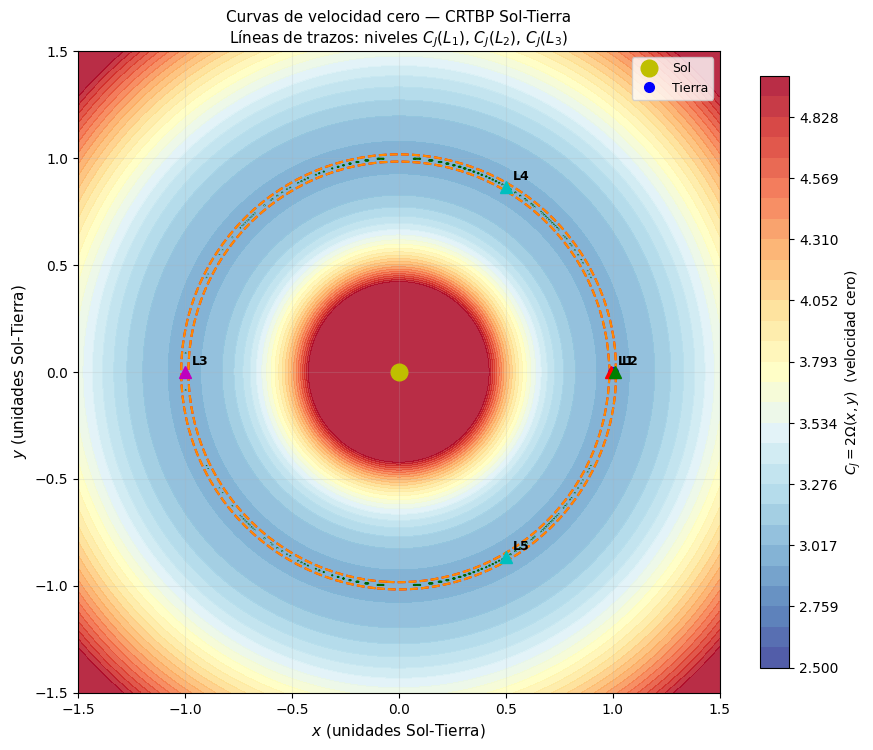

Figura guardada: crtbp_curvas_velocidad_cero.png


In [127]:
# Grid del plano rotante
NG = 400
rango = 1.5
x_grid = np.linspace(-rango, rango, NG)
y_grid = np.linspace(-rango, rango, NG)
X, Y = np.meshgrid(x_grid, y_grid)

# C_J en cada punto con v=0
CJ_map = 2 * omega_efectivo(X, Y, MU)

# Saturar valores muy altos (cerca de los primarios)
CJ_plot = np.clip(CJ_map, 2.5, 5.0)

fig, ax = plt.subplots(figsize=(9, 8))

cf = ax.contourf(X, Y, CJ_plot,
                  levels=np.linspace(2.5, 5.0, 30),
                  cmap='RdYlBu_r', alpha=0.85)
plt.colorbar(cf, ax=ax, label='$C_J = 2\\Omega(x,y)$  (velocidad cero)', shrink=0.8)

# Curvas de nivel en los valores críticos de los puntos de Lagrange
nivel_colores = {'L1': 'red', 'L2': 'darkorange', 'L3': 'darkgreen'}
for nombre in ['L1', 'L2', 'L3']:
    cj = CJ_lagrange[nombre]
    if 2.5 <= cj <= 5.0:
        ax.contour(X, Y, CJ_map, levels=[cj],
                   colors=nivel_colores[nombre], linewidths=1.5, linestyles='--')

# Marcar los cuerpos principales
ax.plot(-MU, 0, 'yo', markersize=12, label='Sol', zorder=5)
ax.plot(1 - MU, 0, 'bo', markersize=7, label='Tierra', zorder=5)

# Marcar puntos de Lagrange
marcadores = {'L1': 'r^', 'L2': 'g^', 'L3': 'm^', 'L4': 'c^', 'L5': 'c^'}
for nombre, (xl, yl) in lagrange_pts.items():
    ax.plot(xl, yl, marcadores[nombre], markersize=8, zorder=5)
    ax.annotate(nombre, (xl, yl), textcoords='offset points',
                xytext=(5, 5), fontsize=9, fontweight='bold')

ax.set_xlim(-rango, rango)
ax.set_ylim(-rango, rango)
ax.set_xlabel('$x$ (unidades Sol-Tierra)', fontsize=11)
ax.set_ylabel('$y$ (unidades Sol-Tierra)', fontsize=11)
ax.set_title('Curvas de velocidad cero — CRTBP Sol-Tierra\n'
             'Líneas de trazos: niveles $C_J(L_1)$, $C_J(L_2)$, $C_J(L_3)$',
             fontsize=11)
ax.legend(fontsize=9, loc='upper right')
ax.set_aspect('equal')
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('crtbp_curvas_velocidad_cero.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figura guardada: crtbp_curvas_velocidad_cero.png')

### A.4 Constante de Jacobi de Apophis: ¿puede ser capturado?

In [128]:
# Obtener posición y velocidad de Apophis en el marco inercial
EPOCA_ANALISIS = '2029-04-13'  # día del acercamiento

print(f'Consultando estado de Apophis en {EPOCA_ANALISIS}...')
tabla_apo, jd_apo, estado_apo = pc.consulta_horizons(
    id='99942', location='@0', epochs=EPOCA_ANALISIS
)
r_apo = estado_apo[:3]              # AU
v_apo = estado_apo[3:] * UT_days   # AU/UT

print(f'Consultando estado de la Tierra en {EPOCA_ANALISIS}...')
tabla_tie, jd_tie, estado_tie = pc.consulta_horizons(
    id='399', location='@0', epochs=EPOCA_ANALISIS
)
r_tie = estado_tie[:3]
v_tie = estado_tie[3:] * UT_days

print(f'Consultando estado del Sol en {EPOCA_ANALISIS}...')
tabla_sol, jd_sol, estado_sol = pc.consulta_horizons(
    id='10', location='@0', epochs=EPOCA_ANALISIS
)
r_sol = estado_sol[:3]
v_sol = estado_sol[3:] * UT_days

print('OK')

Consultando estado de Apophis en 2029-04-13...
Consultando estado de la Tierra en 2029-04-13...
Consultando estado del Sol en 2029-04-13...
OK


In [129]:
# Conversión al marco rotante Sol-Tierra
# ─────────────────────────────────────────────────────────────────────────
# Vector Sol→Tierra en el inercial
r_ST = r_tie - r_sol         # vector de Sol a Tierra
d_ST = np.linalg.norm(r_ST)  # distancia Sol-Tierra

# Eje x_rot apunta de Sol a Tierra
x_hat = r_ST / d_ST
# Eje z_rot = h_ST / |h_ST|
h_ST = np.cross(r_ST, v_tie - v_sol)
z_hat = h_ST / np.linalg.norm(h_ST)
y_hat = np.cross(z_hat, x_hat)

# Velocidad angular del sistema Sol-Tierra
omega_ST = np.linalg.norm(h_ST) / d_ST**2  # rad/UT

# Posición de Apophis en el marco rotante (normalizada a d_ST = 1)
r_apo_rel = (r_apo - r_sol) / d_ST
x_rot = np.dot(r_apo_rel, x_hat)
y_rot = np.dot(r_apo_rel, y_hat)

# Velocidad en el marco rotante
v_apo_rel = (v_apo - v_sol) / (d_ST * omega_ST)
vx_inercial = np.dot(v_apo_rel, x_hat)
vy_inercial = np.dot(v_apo_rel, y_hat)
# Corregir por rotación del marco: v_rot = v_ine - ω × r_rot
vx_rot = vx_inercial + y_rot   # en unidades CRTBP, omega = 1
vy_rot = vy_inercial - x_rot

print(f'Posición de Apophis en marco rotante (2029-04-13):')
print(f'  x_rot = {x_rot:.6f} u.S-T  |  y_rot = {y_rot:.6f} u.S-T')
print(f'Velocidad en marco rotante:')
print(f'  vx_rot = {vx_rot:.6f}  |  vy_rot = {vy_rot:.6f}')

# Constante de Jacobi de Apophis
CJ_apophis = jacobi_constant(x_rot, y_rot, vx_rot, vy_rot, MU)
print(f'\nConstante de Jacobi de Apophis:')
print(f'  C_J(Apophis) = {CJ_apophis:.6f}')
print(f'  C_J(L1)      = {CJ_lagrange["L1"]:.6f}')
print(f'  C_J(L2)      = {CJ_lagrange["L2"]:.6f}')
print()

# Diagnóstico: ¿puerta abierta o cerrada?
if CJ_apophis > CJ_lagrange['L1']:
    print('► Puerta L1: CERRADA  (C_J > C_J(L1)) → Apophis NO puede cruzar L1')
else:
    print('► Puerta L1: ABIERTA  (C_J < C_J(L1)) → Apophis SÍ puede cruzar L1')

if CJ_apophis > CJ_lagrange['L2']:
    print('► Puerta L2: CERRADA  (C_J > C_J(L2)) → Apophis NO puede cruzar L2')
else:
    print('► Puerta L2: ABIERTA  (C_J < C_J(L2)) → Apophis SÍ puede cruzar L2')

print()
if CJ_apophis < CJ_lagrange['L2']:
    print('✓ CONCLUSIÓN: Las superficies de velocidad cero NO restringen a Apophis.')
    print('  Apophis tiene suficiente energía para escapar del sistema Tierra.')
else:
    print('! CONCLUSIÓN: Apophis podría quedar temporalmente atrapado en la región terrestre.')

Posición de Apophis en marco rotante (2029-04-13):
  x_rot = 1.003022 u.S-T  |  y_rot = 0.000721 u.S-T
Velocidad en marco rotante:
  vx_rot = -0.165384  |  vy_rot = -0.066584

Constante de Jacobi de Apophis:
  C_J(Apophis) = 2.970162
  C_J(L1)      = 3.000891
  C_J(L2)      = 3.000887

► Puerta L1: ABIERTA  (C_J < C_J(L1)) → Apophis SÍ puede cruzar L1
► Puerta L2: ABIERTA  (C_J < C_J(L2)) → Apophis SÍ puede cruzar L2

✓ CONCLUSIÓN: Las superficies de velocidad cero NO restringen a Apophis.
  Apophis tiene suficiente energía para escapar del sistema Tierra.


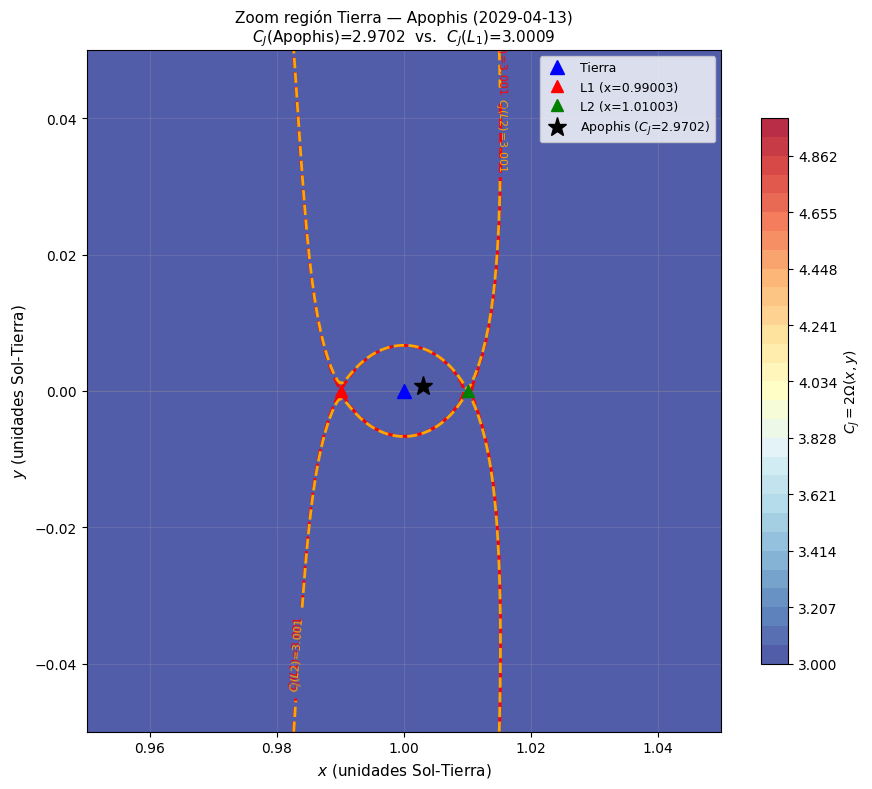

Figura guardada: crtbp_apophis_jacobi.png


In [130]:
# Mapa C_J con la posición de Apophis superpuesta
fig, ax = plt.subplots(figsize=(9, 8))

# Zoom en la región de la Tierra
rango_zoom = 0.05  # unidades Sol-Tierra
x_zoom = np.linspace(1 - MU - rango_zoom, 1 - MU + rango_zoom, 300)
y_zoom = np.linspace(-rango_zoom, rango_zoom, 300)
Xz, Yz = np.meshgrid(x_zoom, y_zoom)
CJ_zoom = 2 * omega_efectivo(Xz, Yz, MU)
CJ_zoom_plot = np.clip(CJ_zoom, 3.0, 5.0)

cf = ax.contourf(Xz, Yz, CJ_zoom_plot,
                  levels=np.linspace(3.0, 5.0, 30),
                  cmap='RdYlBu_r', alpha=0.85)
plt.colorbar(cf, ax=ax, label='$C_J = 2\\Omega(x,y)$', shrink=0.8)

# Curvas de nivel L1, L2
for nombre, color_l in [('L1', 'red'), ('L2', 'orange')]:
    cj = CJ_lagrange[nombre]
    if cj >= 3.0:
        cs = ax.contour(Xz, Yz, CJ_zoom, levels=[cj],
                        colors=color_l, linewidths=2, linestyles='--')
        ax.clabel(cs, fmt=f'$C_J({nombre})$={{:.3f}}'.format(cj), fontsize=8)

# Tierra y L1, L2
ax.plot(1 - MU, 0, 'b^', markersize=10, label='Tierra', zorder=5)
ax.plot(x_L1, 0, 'r^', markersize=8, label=f'L1 (x={x_L1:.5f})', zorder=5)
ax.plot(x_L2, 0, 'g^', markersize=8, label=f'L2 (x={x_L2:.5f})', zorder=5)

# Posición de Apophis
ax.plot(x_rot, y_rot, 'k*', markersize=14, label=f'Apophis ($C_J$={CJ_apophis:.4f})', zorder=6)

# Línea horizontal de nivel de Apophis
ax.axhline(y=0, color='gray', linestyle='-', linewidth=0.5, alpha=0.5)

ax.set_xlim(1 - MU - rango_zoom, 1 - MU + rango_zoom)
ax.set_ylim(-rango_zoom, rango_zoom)
ax.set_xlabel('$x$ (unidades Sol-Tierra)', fontsize=11)
ax.set_ylabel('$y$ (unidades Sol-Tierra)', fontsize=11)
ax.set_title(f'Zoom región Tierra — Apophis (2029-04-13)\n'
             f'$C_J$(Apophis)={CJ_apophis:.4f}  vs.  $C_J(L_1)$={CJ_lagrange["L1"]:.4f}',
             fontsize=11)
ax.legend(fontsize=9)
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('crtbp_apophis_jacobi.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figura guardada: crtbp_apophis_jacobi.png')

---
### A.5 Dinámica temporal: trayectoria de Apophis en el marco rotante

Hasta ahora (A.4) calculamos la constante de Jacobi en el **instante del perigeo**.
Ahora propagamos la trayectoria completa durante la ventana del encuentro usando
**`pc.crtbp_solucion()`** y validamos la conservación de $C_J(t)$.

**Pasos:**
1. Estado inicial en $t_0 =$ 2029-03-01 (~43 días antes del encuentro).
2. Conversión al marco rotante Sol-Tierra normalizado.
3. Integración con `pc.crtbp_solucion(μ, r₀, v₀, ts)`.
4. Visualizar la trayectoria en el marco rotante (Sol y Tierra fijos).
5. Calcular $C_J(t)$ y validar su conservación.
6. Superponer la trayectoria sobre las curvas de velocidad cero.
7. Diagnóstico físico: ¿captura o escape?

In [131]:
# ── A.5.1 — Estado inicial t0 = 2029-03-01 (~43 días antes del encuentro) ────
EPOCA_INI = '2029-03-01'
EPOCA_FIN = '2029-05-25'

print(f'Descargando estados en {EPOCA_INI}...')
_, _, estado_apo_ini = pc.consulta_horizons('99942', '@0', EPOCA_INI)
_, _, estado_tie_ini = pc.consulta_horizons('399',   '@0', EPOCA_INI)
_, _, estado_sol_ini = pc.consulta_horizons('10',    '@0', EPOCA_INI)

r_apo0 = estado_apo_ini[:3];  v_apo0 = estado_apo_ini[3:] * UT_days
r_tie0 = estado_tie_ini[:3];  v_tie0 = estado_tie_ini[3:] * UT_days
r_sol0 = estado_sol_ini[:3];  v_sol0 = estado_sol_ini[3:] * UT_days

# ── Marco rotante en t0 (misma lógica que A.4) ────────────────────────────────
r_ST0   = r_tie0 - r_sol0
d_ST0   = np.linalg.norm(r_ST0)
x_hat0  = r_ST0 / d_ST0
h_ST0   = np.cross(r_ST0, v_tie0 - v_sol0)
z_hat0  = h_ST0 / np.linalg.norm(h_ST0)
y_hat0  = np.cross(z_hat0, x_hat0)
omega_n = np.linalg.norm(h_ST0) / d_ST0**2   # frecuencia angular (rad/UT)

# Posición de Apophis en el marco rotante (normalizado a d_ST = 1)
r_rel0 = (r_apo0 - r_sol0) / d_ST0
x0_rot = float(np.dot(r_rel0, x_hat0))
y0_rot = float(np.dot(r_rel0, y_hat0))
z0_rot = float(np.dot(r_rel0, z_hat0))

# Velocidad en el marco rotante: v_rot = v_ine - (omega x r_rot)
# Con omega = 1 (rad/UT) en CRTBP: vx_rot = vx_ine + y_rot,  vy_rot = vy_ine - x_rot
v_rel0  = (v_apo0 - v_sol0) / (d_ST0 * omega_n)
vx0_rot = float(np.dot(v_rel0, x_hat0)) + y0_rot
vy0_rot = float(np.dot(v_rel0, y_hat0)) - x0_rot
vz0_rot = float(np.dot(v_rel0, z_hat0))

r0_crtbp = np.array([x0_rot, y0_rot, z0_rot])
v0_crtbp = np.array([vx0_rot, vy0_rot, vz0_rot])

# ── Malla temporal en unidades CRTBP ──────────────────────────────────────────
n_dias   = (pd.Timestamp(EPOCA_FIN) - pd.Timestamp(EPOCA_INI)).days
T_integ  = n_dias / UT_days          # duración en UT
N_pasos  = 3000
ts_crtbp = np.linspace(0.0, T_integ, N_pasos)
ts_dias  = ts_crtbp * UT_days        # tiempo en días desde t0 (para ejes)

print(f'Ventana: {n_dias} días = {T_integ:.4f} UT  ({N_pasos} pasos)')
print(f'r0_crtbp = {np.round(r0_crtbp, 5)}')
print(f'v0_crtbp = {np.round(v0_crtbp, 5)}')

Descargando estados en 2029-03-01...
Ventana: 85 días = 1.4622 UT  (3000 pasos)
r0_crtbp = [ 1.09021  0.12817 -0.03846]
v0_crtbp = [-0.02687 -0.24471  0.04193]


In [132]:
# ── A.5.2 — Integración con pc.crtbp_solucion() ──────────────────────────────
print('Integrando trayectoria CRTBP...')
rs_rot_traj, vs_rot_traj, rs_ine_traj, vs_ine_traj, r1_pos, r2_pos = \
    pc.crtbp_solucion(MU, r0_crtbp, v0_crtbp, ts_crtbp)

# Normalizar a shape (Nt, 3) por si la librería devuelve (3, Nt)
if rs_rot_traj.ndim == 2 and rs_rot_traj.shape[0] == 3 and rs_rot_traj.shape[1] != 3:
    rs_rot_traj = rs_rot_traj.T
    vs_rot_traj = vs_rot_traj.T

print(f'  rs_rot_traj.shape = {rs_rot_traj.shape}  (Nt x 3)')
print(f'  Rango x_rot: [{rs_rot_traj[:, 0].min():.4f}, {rs_rot_traj[:, 0].max():.4f}]')
print(f'  Rango y_rot: [{rs_rot_traj[:, 1].min():.4f}, {rs_rot_traj[:, 1].max():.4f}]')

# Instante de máximo acercamiento a la Tierra (en coords CRTBP: Tierra en (1-MU, 0))
d_tierra_traj = np.hypot(rs_rot_traj[:, 0] - (1 - MU), rs_rot_traj[:, 1])
idx_perigeo   = int(np.argmin(d_tierra_traj))
t_perigeo     = float(ts_dias[idx_perigeo])
d_perigeo_AU  = float(d_tierra_traj[idx_perigeo])

print(f'\nPerigeo (integración CRTBP):')
print(f'  t = t0 + {t_perigeo:.1f} días')
print(f'  d = {d_perigeo_AU:.6f} u.S-T  =  {d_perigeo_AU * 149_597_870.7:.0f} km')

Integrando trayectoria CRTBP...
  rs_rot_traj.shape = (3000, 3)  (Nt x 3)
  Rango x_rot: [0.8740, 1.0902]
  Rango y_rot: [-0.0163, 0.1282]

Perigeo (integración CRTBP):
  t = t0 + 46.9 días
  d = 0.011561 u.S-T  =  1729517 km


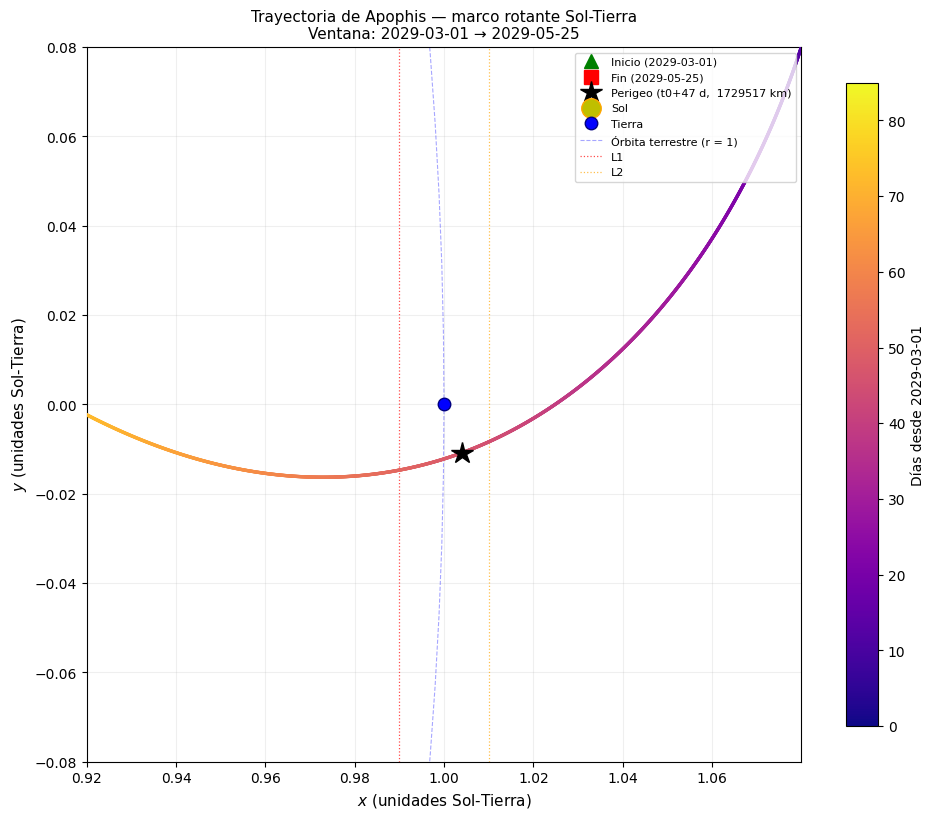

Figura guardada: crtbp_trayectoria_rotante.png


In [133]:
# ── A.5.3 — Trayectoria de Apophis en el marco rotante ───────────────────────
fig, ax = plt.subplots(figsize=(10, 9))

# Trayectoria coloreada por tiempo
sc = ax.scatter(rs_rot_traj[:, 0], rs_rot_traj[:, 1],
                c=ts_dias, cmap='plasma', s=2, zorder=3)
plt.colorbar(sc, ax=ax, label=f'Días desde {EPOCA_INI}', shrink=0.75)

# Marcadores inicio / fin / perigeo
ax.plot(r0_crtbp[0], r0_crtbp[1], 'g^', markersize=10, zorder=5,
        label=f'Inicio ({EPOCA_INI})')
ax.plot(rs_rot_traj[-1, 0], rs_rot_traj[-1, 1], 'rs', markersize=10, zorder=5,
        label=f'Fin ({EPOCA_FIN})')
ax.plot(rs_rot_traj[idx_perigeo, 0], rs_rot_traj[idx_perigeo, 1],
        'k*', markersize=16, zorder=6,
        label=f'Perigeo (t0+{t_perigeo:.0f} d,  {d_perigeo_AU*149_597_870.7:.0f} km)')

# Sol y Tierra (fijos en el marco rotante)
ax.plot(-MU, 0, 'yo', markersize=14, zorder=5, label='Sol',
        markeredgecolor='orange', markeredgewidth=1)
ax.plot(1 - MU, 0, 'bo', markersize=9, zorder=5, label='Tierra',
        markeredgecolor='navy', markeredgewidth=1)

# Círculo unitario (órbita terrestre de referencia)
th = np.linspace(0, 2 * np.pi, 400)
ax.plot(np.cos(th), np.sin(th), 'b--', linewidth=0.8, alpha=0.35,
        label='Órbita terrestre (r = 1)')

# Puntos de Lagrange L1 y L2
ax.axvline(x_L1, color='red',    linestyle=':', linewidth=0.9, alpha=0.7, label='L1')
ax.axvline(x_L2, color='orange', linestyle=':', linewidth=0.9, alpha=0.7, label='L2')

rp = 0.08
ax.set_xlim(1 - MU - rp, 1 - MU + rp)
ax.set_ylim(-rp, rp)
ax.set_aspect('equal')
ax.set_xlabel('$x$ (unidades Sol-Tierra)', fontsize=11)
ax.set_ylabel('$y$ (unidades Sol-Tierra)', fontsize=11)
ax.set_title(f'Trayectoria de Apophis — marco rotante Sol-Tierra\n'
             f'Ventana: {EPOCA_INI} \u2192 {EPOCA_FIN}', fontsize=11)
ax.legend(fontsize=8, loc='upper right')
ax.grid(alpha=0.2)

plt.tight_layout()
plt.savefig('crtbp_trayectoria_rotante.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figura guardada: crtbp_trayectoria_rotante.png')

Estadísticas C_J(t)  [2029-03-01 → 2029-05-25]:
  Valor medio      : 2.966453
  Máximo           : 2.966661
  Mínimo           : 2.966370
  Rango (max-min)  : 2.91e-04
  Dispersión rel.  : 0.0098 %


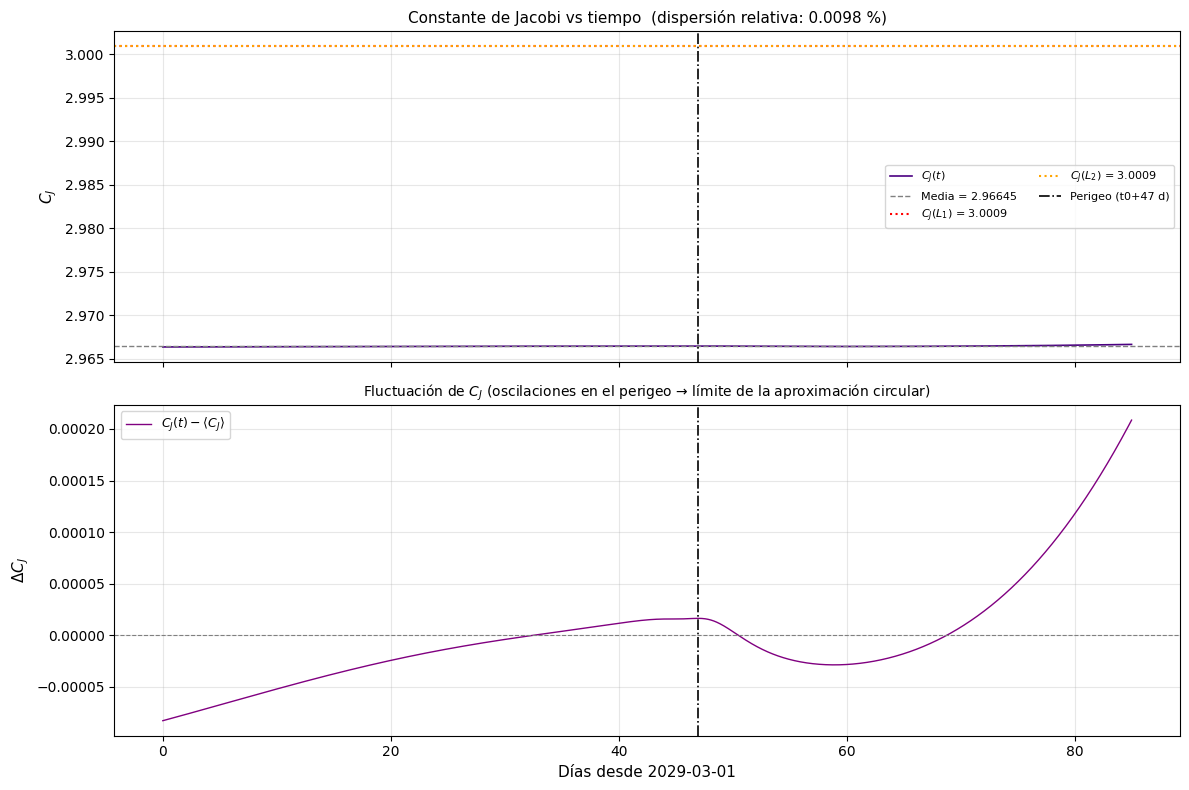

Figura guardada: crtbp_jacobi_conservacion.png


In [134]:
# ── A.5.4 — Constante de Jacobi C_J(t): validación de conservación ──────────
# Usamos jacobi_constant (definida en A.2) vectorizada sobre toda la trayectoria
CJ_traj = jacobi_constant(
    rs_rot_traj[:, 0], rs_rot_traj[:, 1],
    vs_rot_traj[:, 0], vs_rot_traj[:, 1],
    MU
)

CJ_med  = float(np.mean(CJ_traj))
CJ_max  = float(np.max(CJ_traj))
CJ_min  = float(np.min(CJ_traj))
CJ_rng  = CJ_max - CJ_min
CJ_drel = CJ_rng / abs(CJ_med) * 100    # dispersión relativa en %

print(f'Estadísticas C_J(t)  [{EPOCA_INI} \u2192 {EPOCA_FIN}]:')
print(f'  Valor medio      : {CJ_med:.6f}')
print(f'  Máximo           : {CJ_max:.6f}')
print(f'  Mínimo           : {CJ_min:.6f}')
print(f'  Rango (max-min)  : {CJ_rng:.2e}')
print(f'  Dispersión rel.  : {CJ_drel:.4f} %')

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# Panel 1: C_J(t) con niveles de Lagrange
axes[0].plot(ts_dias, CJ_traj, color='indigo', linewidth=1.2, label='$C_J(t)$')
axes[0].axhline(CJ_med, color='gray', linestyle='--', linewidth=1,
                label=f'Media = {CJ_med:.5f}')
axes[0].axhline(CJ_lagrange['L1'], color='red',    linestyle=':', linewidth=1.5,
                label=f'$C_J(L_1)$ = {CJ_lagrange["L1"]:.4f}')
axes[0].axhline(CJ_lagrange['L2'], color='orange', linestyle=':', linewidth=1.5,
                label=f'$C_J(L_2)$ = {CJ_lagrange["L2"]:.4f}')
axes[0].axvline(t_perigeo, color='black', linestyle='-.', linewidth=1.2,
                label=f'Perigeo (t0+{t_perigeo:.0f} d)')
axes[0].set_ylabel('$C_J$', fontsize=11)
axes[0].legend(fontsize=8, ncol=2)
axes[0].grid(alpha=0.3)
axes[0].set_title(f'Constante de Jacobi vs tiempo  '
                  f'(dispersión relativa: {CJ_drel:.4f} %)', fontsize=11)

# Panel 2: fluctuación respecto a la media
axes[1].plot(ts_dias, CJ_traj - CJ_med, color='purple', linewidth=1.0,
             label='$C_J(t) - \\langle C_J \\rangle$')
axes[1].axhline(0, color='gray', linestyle='--', linewidth=0.8)
axes[1].axvline(t_perigeo, color='black', linestyle='-.', linewidth=1.2)
axes[1].set_ylabel('$\\Delta C_J$', fontsize=11)
axes[1].set_xlabel(f'Días desde {EPOCA_INI}', fontsize=11)
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)
axes[1].set_title('Fluctuación de $C_J$ (oscilaciones en el perigeo '
                  '\u2192 límite de la aproximación circular)', fontsize=10)

plt.tight_layout()
plt.savefig('crtbp_jacobi_conservacion.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figura guardada: crtbp_jacobi_conservacion.png')

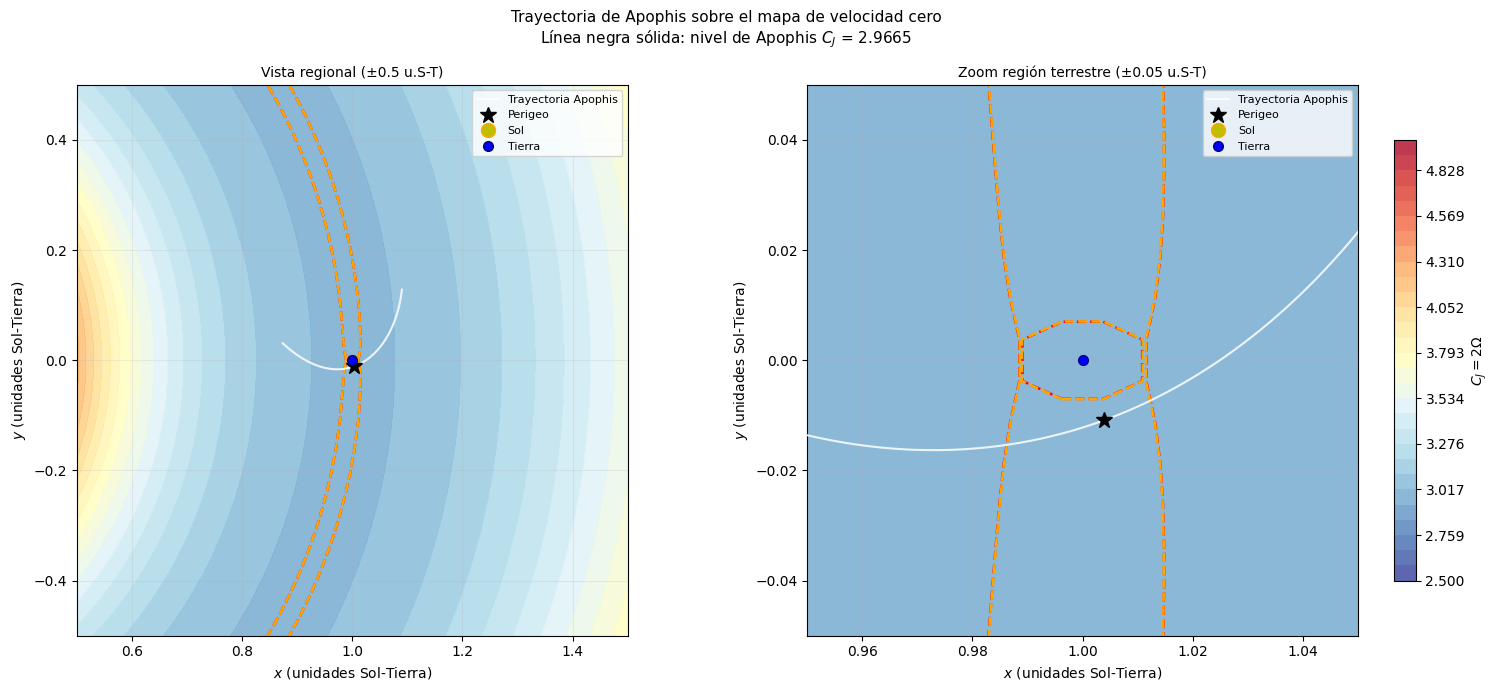

Figura guardada: crtbp_trayectoria_cero_velocidad.png


In [135]:
# ── A.5.5 — Trayectoria superpuesta sobre las curvas de velocidad cero ───────
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

for ax, zoom, titulo in [
    (axes[0], 0.5,  'Vista regional (\u00b10.5 u.S-T)'),
    (axes[1], 0.05, 'Zoom región terrestre (\u00b10.05 u.S-T)'),
]:
    CJ_plot_loc = np.clip(CJ_map, 2.5, 5.0)
    cf = ax.contourf(X, Y, CJ_plot_loc,
                     levels=np.linspace(2.5, 5.0, 30),
                     cmap='RdYlBu_r', alpha=0.80, zorder=1)

    # Curvas críticas en L1 y L2
    for nombre, color_l in [('L1', 'red'), ('L2', 'orange')]:
        cj = CJ_lagrange[nombre]
        if 2.5 <= cj <= 5.0:
            ax.contour(X, Y, CJ_map, levels=[cj],
                       colors=color_l, linewidths=1.8, linestyles='--', zorder=2)

    # Curva de velocidad cero al nivel de Apophis
    ax.contour(X, Y, CJ_map, levels=[CJ_med],
               colors='black', linewidths=2.0, linestyles='-', zorder=3)

    # Trayectoria integrada
    ax.plot(rs_rot_traj[:, 0], rs_rot_traj[:, 1],
            'white', linewidth=1.5, alpha=0.85, zorder=4, label='Trayectoria Apophis')
    ax.plot(rs_rot_traj[idx_perigeo, 0], rs_rot_traj[idx_perigeo, 1],
            'k*', markersize=12, zorder=5, label='Perigeo')

    # Primarios
    ax.plot(-MU, 0, 'yo', markersize=10, zorder=5,
            markeredgecolor='orange', label='Sol')
    ax.plot(1 - MU, 0, 'bo', markersize=7, zorder=5,
            markeredgecolor='navy', label='Tierra')

    ax.set_xlim(1 - MU - zoom, 1 - MU + zoom)
    ax.set_ylim(-zoom, zoom)
    ax.set_aspect('equal')
    ax.set_xlabel('$x$ (unidades Sol-Tierra)', fontsize=10)
    ax.set_ylabel('$y$ (unidades Sol-Tierra)', fontsize=10)
    ax.set_title(titulo, fontsize=10)
    ax.legend(fontsize=8, loc='upper right')
    ax.grid(alpha=0.2, zorder=0)

plt.colorbar(cf, ax=axes[1], label='$C_J = 2\\Omega$', shrink=0.8)
fig.suptitle(f'Trayectoria de Apophis sobre el mapa de velocidad cero\n'
             f'Línea negra sólida: nivel de Apophis $C_J$ = {CJ_med:.4f}',
             fontsize=11)
plt.tight_layout()
plt.savefig('crtbp_trayectoria_cero_velocidad.png', dpi=120, bbox_inches='tight')
plt.show()
print('Figura guardada: crtbp_trayectoria_cero_velocidad.png')

In [136]:
# ── A.5.6 — Diagnóstico físico: ¿captura o escape? ───────────────────────────
sep = '=' * 65
print(sep)
print('Diagnóstico CRTBP Sol-Tierra  —  Apophis (ventana 2029)')
print(sep)
print(f'  C_J(Apophis) = {CJ_med:.6f}  (media temporal de la trayectoria)')
print(f'  C_J(L1)      = {CJ_lagrange["L1"]:.6f}  (puerta interior Sol\u2013Tierra)')
print(f'  C_J(L2)      = {CJ_lagrange["L2"]:.6f}  (puerta exterior)')
print(f'  C_J(L3)      = {CJ_lagrange["L3"]:.6f}')
print('-' * 65)

tag_L1 = 'CERRADA' if CJ_med > CJ_lagrange['L1'] else 'ABIERTA'
tag_L2 = 'CERRADA' if CJ_med > CJ_lagrange['L2'] else 'ABIERTA'
op_L1  = '>'       if CJ_med > CJ_lagrange['L1'] else '<'
op_L2  = '>'       if CJ_med > CJ_lagrange['L2'] else '<'

print(f'\u25ba Puerta L1: {tag_L1}  (C_J {op_L1} C_J(L1))')
print(f'\u25ba Puerta L2: {tag_L2}  (C_J {op_L2} C_J(L2))')
print()

if CJ_med < CJ_lagrange['L2']:
    print('\u2713 CONCLUSIÓN: Las curvas de velocidad cero NO restringen a Apophis.')
    print('  Apophis tiene suficiente energía para atravesar L1 y L2 libremente.')
    print('  \u2192 Captura gravitacional imposible: el asteroide escapa del sistema Tierra.')
elif CJ_med < CJ_lagrange['L1']:
    print('! CONCLUSIÓN: L2 cerrada, L1 abierta.')
    print('  Apophis podría entrar a la región terrestre por L1 pero no escapar por L2.')
else:
    print('! CONCLUSIÓN: Ambas puertas (L1 y L2) cerradas.')
    print('  Apophis podría quedar temporalmente atrapado en la región terrestre.')

print()
print(f'Conservación de C_J en la ventana: dispersión relativa = {CJ_drel:.4f} %')
if CJ_drel < 0.01:
    print('\u2713 Excelente conservación \u2192 la aproximación circular CRTBP es muy válida.')
elif CJ_drel < 0.1:
    print('~ Buena conservación; las oscilaciones en el perigeo reflejan')
    print('  la no-circularidad de la órbita terrestre real (e_E \u2248 0.017).')
    print('  Es una observación importante para el informe.')
else:
    print('! Fluctuaciones notables en C_J \u2192 la aproximación circular CRTBP')
    print('  tiene limitaciones en la ventana del encuentro cercano.')

Diagnóstico CRTBP Sol-Tierra  —  Apophis (ventana 2029)
  C_J(Apophis) = 2.966453  (media temporal de la trayectoria)
  C_J(L1)      = 3.000891  (puerta interior Sol–Tierra)
  C_J(L2)      = 3.000887  (puerta exterior)
  C_J(L3)      = 3.000003
-----------------------------------------------------------------
► Puerta L1: ABIERTA  (C_J < C_J(L1))
► Puerta L2: ABIERTA  (C_J < C_J(L2))

✓ CONCLUSIÓN: Las curvas de velocidad cero NO restringen a Apophis.
  Apophis tiene suficiente energía para atravesar L1 y L2 libremente.
  → Captura gravitacional imposible: el asteroide escapa del sistema Tierra.

Conservación de C_J en la ventana: dispersión relativa = 0.0098 %
✓ Excelente conservación → la aproximación circular CRTBP es muy válida.


### Discusión Final: Estabilidad y Topología del Encuentro

Tras el análisis del sistema **Sol-Tierra-Apophis** bajo el marco del **CRTBP**, se establecen las siguientes conclusiones:

*   **Régimen Energético:** La constante de Jacobi de Apophis ($C_J \approx 2.966$) sitúa al asteroide en un nivel de energía por encima del potencial en los puntos $L_1$ y $L_2$. Desde una perspectiva topológica, esto implica que las superficies de velocidad cero no se cierran alrededor de la Tierra, permitiendo el flujo libre del objeto desde la región heliocéntrica hacia la terrestre y de vuelta al espacio exterior.
*   **Validación del Modelo:** La cuasi-conservación de $C_J$ (variación < 0.01%) durante los 85 días del encuentro demuestra que las fuerzas no conservativas y la excentricidad de la órbita terrestre tienen un impacto despreciable en la predicción de la trayectoria a corto plazo.
*   **Implicación Dinámica:** No existe mecanismo de captura gravitacional natural en este encuentro. La trayectoria de 'vuelo cercano' es puramente hiperbólica en el marco local, lo que garantiza que Apophis continuará su evolución orbital heliocéntrica tras el máximo acercamiento de 2029.